In [1]:
import frc
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from pathlib import Path

DIPlib -- a quantitative image analysis library
Version 3.5.0 (Jun 18 2024)
For more information see https://diplib.org


In [17]:
def crop_center(img,crop_size):

    if type(crop_size) == tuple:
        crop_x,crop_y = crop_size
    elif type(crop_size) == int:
        crop_x = crop_size
        crop_y = crop_size
    
    y,x = img.shape[-2::]
    startx = x//2-(crop_x//2)
    starty = y//2-(crop_y//2)        

    return img[...,starty:starty+crop_y,startx:startx+crop_x]

In [18]:
folder = r"E:\dl_monalisa\Data\Vim_fixed_mltplSNR_30nm\Evaluation\20h12image25nm"
gt = imread(Path(folder) / "gt_gaussblur.tif")
CAREpred = imread(Path(folder) / "CAREpred.tiff")
HDNpred = imread(Path(folder) / "HDNpred_padded.tiff")
N2Vpred = imread(Path(folder) / "N2Vpred.tiff")
UNetRCANpred = imread(Path(folder) / "UNetRCANpred.tiff")

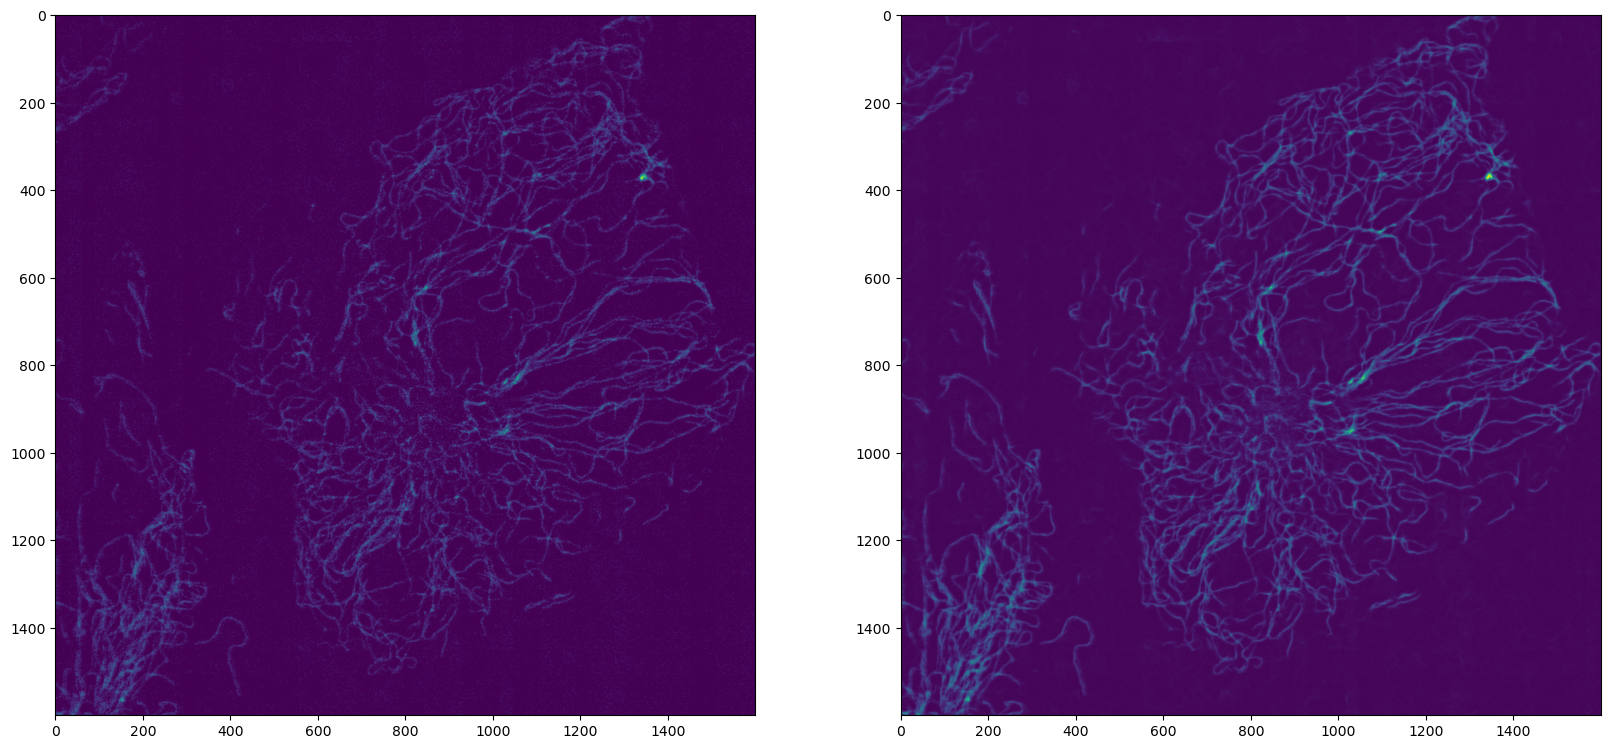

In [19]:
cropsize = 1600
gt=crop_center(gt,cropsize)
gt[gt<0]=0

CAREpred=crop_center(CAREpred,cropsize)
HDNpred=crop_center(HDNpred,cropsize)
N2Vpred=crop_center(N2Vpred,cropsize)
UNetRCANpred=crop_center(UNetRCANpred,cropsize)

plt.figure(figsize=(20,20))
plt.subplot(2,2,1);plt.imshow(gt)
plt.subplot(2,2,2);plt.imshow(CAREpred)

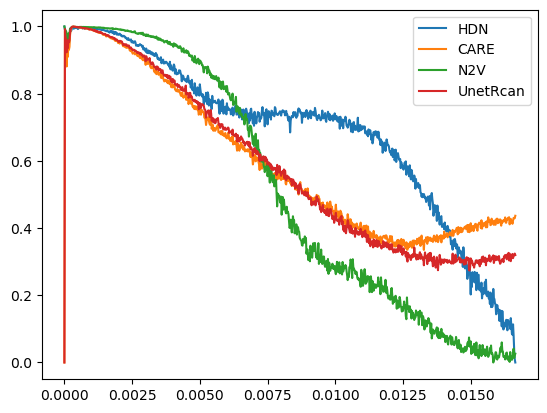

In [20]:
# Input can be a numpy array or DIP image
gt = frc.util.apply_tukey(gt)
HDNpred = frc.util.apply_tukey(HDNpred)
CAREpred = frc.util.apply_tukey(CAREpred)
N2Vpred = frc.util.apply_tukey(N2Vpred)
UNetRCANpred = frc.util.apply_tukey(UNetRCANpred)
labels = ["HDN","CARE","N2V","UnetRcan"]
scale = 1/30# scale has units [pixels <length unit>^-1] corresponding to original image
img_size = gt.shape[0]
plt.figure()
for i,pred in enumerate([HDNpred,CAREpred,N2Vpred,UNetRCANpred]):
    frc_curve = frc.two_frc(gt,pred)
    frc_curve = (frc_curve - np.min(frc_curve)) / (np.max(frc_curve) - np.min(frc_curve))
    xs_pix = np.arange(len(frc_curve)) / img_size
    xs_nm_freq = xs_pix * scale
    frc_res, res_y, thres = frc.frc_res(xs_nm_freq, frc_curve, img_size)
    plt.plot(xs_nm_freq, frc_curve,label=labels[0])
plt.legend()
plt.show()

In [ ]:
import os

# Folder containing the image stacks
folder_path = r'E:\dl_monalisa\Models\Vim_fixed_mltplSNR_30nm\Upsampling_selected\unpaired'

# SNR and filling factor values
snrs = [1, 2, 3]  # Update according to your SNR values
ffs = [0.25, 0.5, 0.75]

# Process each image stack
files = os.listdir(folder_path)
all_frc_curves = []
for file_idx,file_name in enumerate(files):
    if file_name.endswith('.tif'):
        file_path = os.path.join(folder_path, file_name)
        img_stack = imread(file_path)

        # Ground truth (first image in the stack)
        gt = img_stack[0]
        gt = frc.util.apply_tukey(gt)
        
        frc_curves = []
        # calculate frc curves for each pred
        for i, snr in enumerate(snrs):
            for j, filling_factor in enumerate(ffs):
                pred_index = i * len(ffs) + j + 1
                pred = img_stack[pred_index]
                pred = frc.util.apply_tukey(pred)
                frc_curve = frc.two_frc(gt,pred)
                frc_curve = (frc_curve - np.min(frc_curve)) / (np.max(frc_curve) - np.min(frc_curve))
                frc_curves.append(frc_curve)
        
        all_frc_curves.append(np.stack(frc_curves))



In [73]:
scale = 1/30# scale has units [pixels <length unit>^-1] corresponding to original image
img_size = gt.shape[0]

all_frc_curves = np.stack(all_frc_curves)
avg_frc_curves = np.mean(all_frc_curves,axis=0)
std_frc_curves = np.std(all_frc_curves, axis=0)

print(all_frc_curves.shape)
print(avg_frc_curves.shape)
print(std_frc_curves.shape)


(3, 9, 600)
(9, 600)
(9, 600)


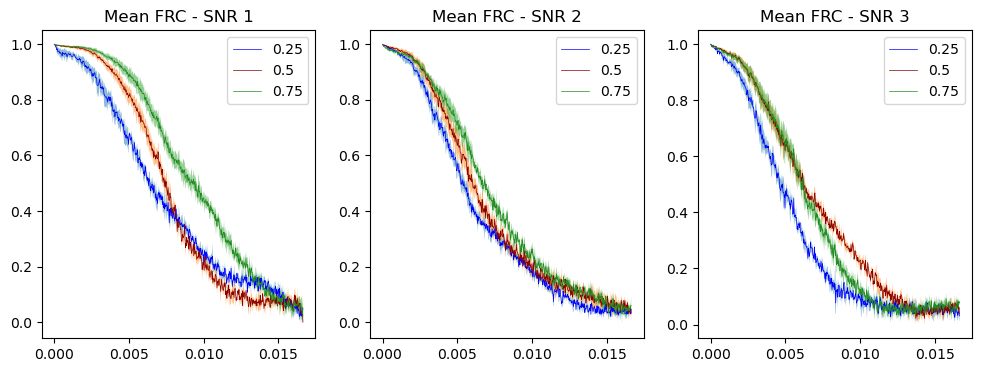

In [83]:
# Plot FRC vs ff for each SNR


colors = ['blue', 'darkred', 'forestgreen']
# Mean FRC plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i,snr in enumerate(snrs):
    axs[i].set_title(f"Mean FRC - SNR {snr}")
    for j,ff in enumerate(ffs):
        idx = i * len(ffs) + j
        frc_curve = avg_frc_curves[idx]
        std_curve = std_frc_curves[idx]

        xs_pix = np.arange(len(frc_curve)) / img_size
        xs_nm_freq = xs_pix * scale
        axs[i].plot(xs_nm_freq, frc_curve,label=ff,linewidth=0.5,color=colors[j])
        axs[i].fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.5)
    axs[i].legend()

plt.show()

# FRC plot for each image
# fig, axs = plt.subplots(3, 3, figsize=(12, 12))
# for img_idx in range(all_frc_curves.shape[0]):
#     for i,snr in enumerate(snrs):
#         axs[img_idx,i].set_title(f"Img{img_idx} FRC - SNR {snr}")
#         for j,ff in enumerate(ffs):
#             idx = i * len(ffs) + j
#             frc_curve = all_frc_curves[img_idx,idx]
#             xs_pix = np.arange(len(frc_curve)) / img_size
#             xs_nm_freq = xs_pix * scale
#             axs[img_idx,i].plot(xs_nm_freq, frc_curve,label=ff,linewidth=0.7,color=colors[j])
#         axs[img_idx,i].legend()


# plt.show()

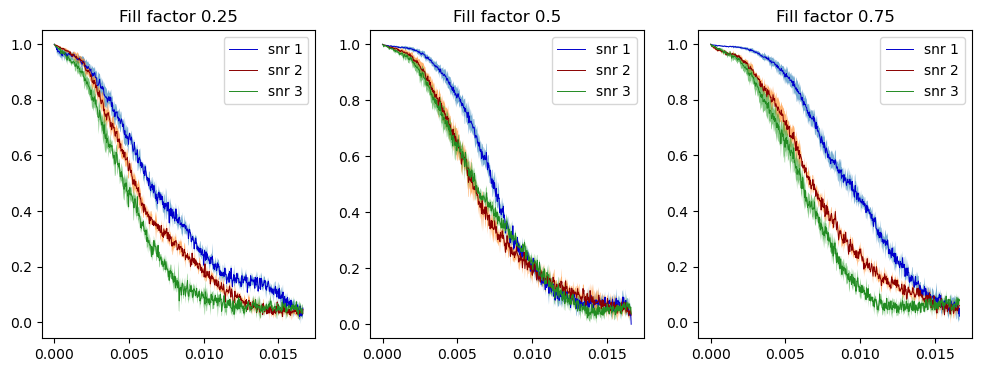

In [63]:
# Plot FRC vs ff for each SNR

# Mean FRC plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i,ff in enumerate(ffs):
    axs[i].set_title(f"Fill factor {ff}")
    for j,snr in enumerate(ffs):
        idx = i + (len(ffs)*(j))
        frc_curve = avg_frc_curves[idx]
        std_curve = std_frc_curves[idx]

        xs_pix = np.arange(len(frc_curve)) / img_size
        xs_nm_freq = xs_pix * scale
        axs[i].plot(xs_nm_freq, frc_curve,label=f"snr {snr}",linewidth=0.7,color=colors[j])
        axs[i].fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.6)
    axs[i].legend()

plt.show()

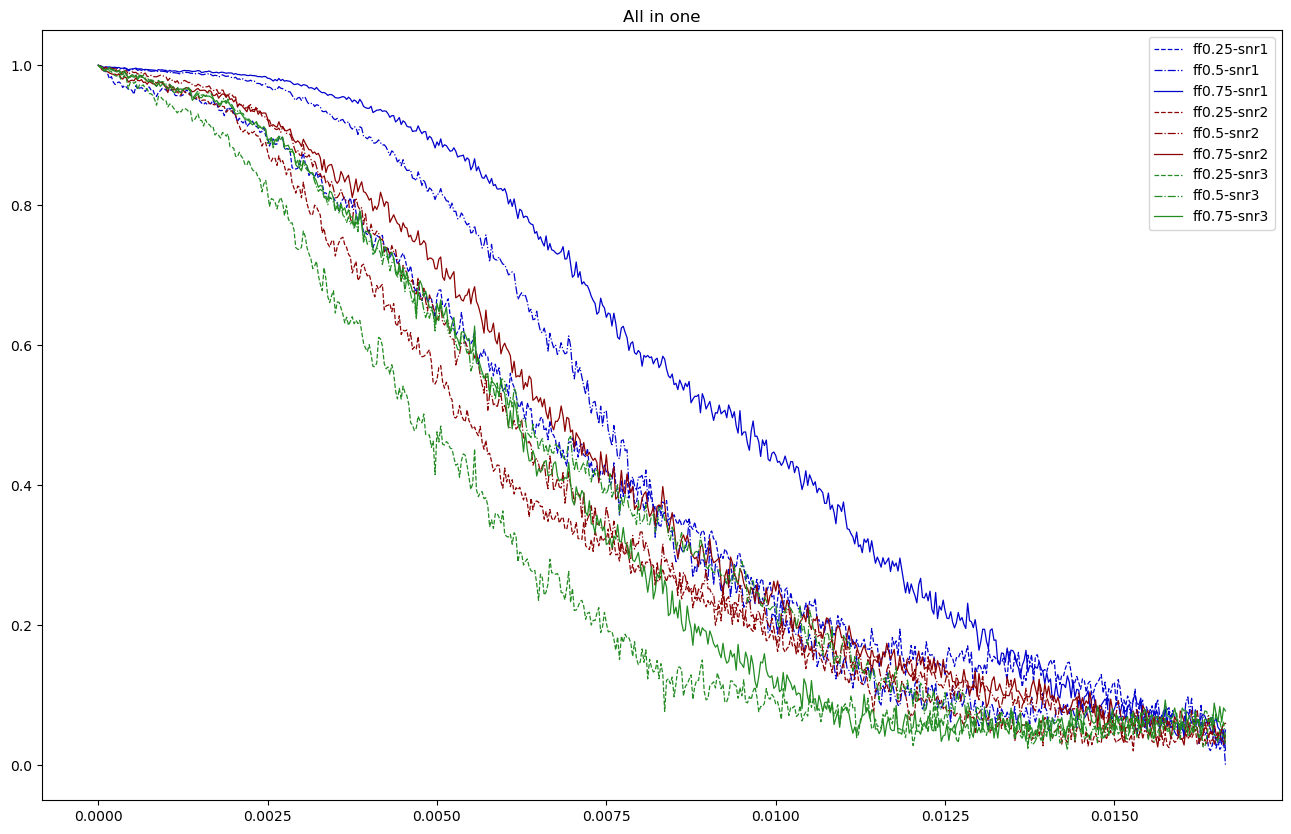

In [72]:
# Plot all in one

scale = 1/30# scale has units [pixels <length unit>^-1] corresponding to original image
img_size = gt.shape[0]

colors = ['mediumblue', 'darkred', 'forestgreen']
markers = ['+', 'o', 'x']
lines = [
    'dashed',
    'dashdot',
    'solid',
]
plt.figure(figsize=(16, 10))
for i,snr in enumerate(snrs):
    plt.title(f"All in one")
    for j,ff in enumerate(ffs):
        idx = i * len(ffs) + j
        frc_curve = avg_frc_curves[idx]
        xs_pix = np.arange(len(frc_curve)) / img_size
        xs_nm_freq = xs_pix * scale
        plt.plot(xs_nm_freq, frc_curve,label=f"ff{ff}-snr{snr}",color=colors[i],linestyle=lines[j],linewidth=0.9)

plt.legend()
plt.show()

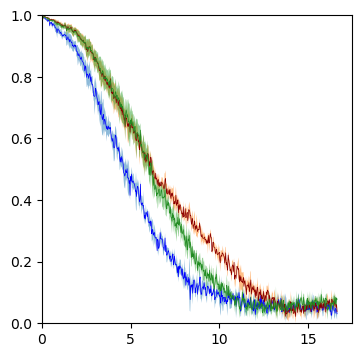

In [108]:
# Save figure for SNR avg only


scale = 1/30*1e3# scale has units [pixels <length unit>^-1] corresponding to original image

colors = ['blue', 'darkred', 'forestgreen']
# Mean FRC plot
fig = plt.figure(figsize=(4, 4))
for j,ff in enumerate(ffs):
    idx = 2 * len(ffs) + j
    frc_curve = avg_frc_curves[idx]
    std_curve = std_frc_curves[idx]

    xs_pix = np.arange(len(frc_curve)) / img_size
    xs_nm_freq = xs_pix * scale
    plt.plot(xs_nm_freq, frc_curve,label=ff,linewidth=0.5,color=colors[j])
    plt.fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.5)
    plt.xlim(0)
    plt.xticks(range(0, 16, 5))
    plt.ylim(0,1)
plt.show()

save_folder = Path(r"\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Upsampling_charac\fixed_snr")

fig.savefig(save_folder/"FRC_snr1_3ff.svg", format="svg", bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

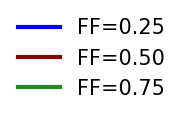

In [106]:
# save legend

from matplotlib.lines import Line2D
fig = plt.figure()
legend_lines = [Line2D([0], [0], color=colors[idx], lw=3) for idx in range(len(ffs))]

# Create a figure for the legend (without axes)
fig = plt.figure(figsize=(2, 1)) 
ax = fig.add_subplot(111)  
ax.set_axis_off()
ax.legend(legend_lines, [f'FF={ff:.2f}' for ff in ffs],
          loc='center', framealpha=1, frameon=False, fontsize=15)

# Remove ticks and labels
ax.set_xticks([])
ax.set_yticks([])
plt.show()

# Save the legend as an SVG
fig.savefig(save_folder/'legend_fill_factor_tight.svg', format='svg', bbox_inches='tight', pad_inches=0.1,transparent=True)